<a href="https://colab.research.google.com/github/aaronhuang317/Titanic-Passenger-Survival-Prediction-and-Risk-Factor-Analysis/blob/main/Titanic-Passenger-Survival-Prediction-and-Risk-Factor-Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 資料初步載入分析

載入seaborn\pandas



In [32]:
import seaborn as sns
import pandas as pd


先調出在saeborn內建之鐵達尼克號乘客資料並進行初步概觀

In [33]:
titanic_df = sns.load_dataset('titanic')
print("titanic 表格頭部5筆資料")
display(titanic_df.head())
print("titanic 表格尾部5筆資料")
display(titanic_df.tail())
print("表格資料型態及資料缺失情形")
display(titanic_df.info())#缺失值,資料類型(int,float,bool,category,object)
print("表格統計數值")
display(titanic_df.describe())#統計數值(min,max,std,mean,25%/50%)

titanic 表格頭部5筆資料


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


titanic 表格尾部5筆資料


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


表格資料型態及資料缺失情形
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


None

表格統計數值


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [34]:
print("\nMissing values per column:")
display(titanic_df.isnull().sum()) #NaN值設為True並計數


Missing values per column:


,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


筆記:以上分析總結資料總數891筆，缺失項由多到少分別為所在甲板層、年齡、及上船港口

後續須分析數據確定缺失項處理方式

In [35]:
# 將資料儲存為 CSV 檔案
titanic_df.to_csv('titanic.csv', index=False)
print("Titanic 資料已儲存為 'titanic.csv'")

# 再下載下來，或儲存到Mounted Google Drive

Titanic 資料已儲存為 'titanic.csv'


將資料分類調出"類別"與"文字"項目

In [36]:
print("表格資料型態")
display(titanic_df.dtypes)
print("將資料中類別及文字類調出並顯示")
titanic_df_category = titanic_df.select_dtypes(include=['object','category'])
display(titanic_df_category.head())

表格資料型態


,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


將資料中類別及文字類調出並顯示


,sex,embarked,class,who,deck,embark_town,alive
0,male,S,Third,man,NaN,Southampton,no
1,female,C,First,woman,C,Cherbourg,yes
2,female,S,Third,woman,NaN,Southampton,yes
3,female,S,First,woman,C,Southampton,yes
4,male,S,Third,man,NaN,Southampton,no


# 缺失資料分析

In [9]:
missing_deck_by_group = titanic_df.groupby(['class', 'sex'])['deck'].apply(lambda x: x.isnull().sum()).reset_index()
missing_deck_by_group.rename(columns={'deck': 'missing_deck_count'}, inplace=True)

print("按艙等和性別分組的甲板缺失值計數：")
display(missing_deck_by_group)

按艙等和性別分組的甲板缺失值計數：


/tmp/ipykernel_391/3157500756.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  missing_deck_by_group = titanic_df.groupby(['class', 'sex'])['deck'].apply(lambda x: x.isnull().sum()).reset_index()


,class,sex,missing_deck_count
0,First,female,13
1,First,male,28
2,Second,female,66
3,Second,male,102
4,Third,female,138
5,Third,male,341


In [10]:
total_passengers_by_group = titanic_df.groupby(['class', 'sex']).size().reset_index(name='total_passengers')

missing_deck_proportion = pd.merge(
    missing_deck_by_group,
    total_passengers_by_group,
    on=['class', 'sex']
)

missing_deck_proportion['missing_deck_ratio'] = missing_deck_proportion['missing_deck_count'] / missing_deck_proportion['total_passengers']

print("按艙等和性別分組的甲板缺失比例：")
display(missing_deck_proportion)

按艙等和性別分組的甲板缺失比例：


/tmp/ipykernel_391/3199062389.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_passengers_by_group = titanic_df.groupby(['class', 'sex']).size().reset_index(name='total_passengers')


,class,sex,missing_deck_count,total_passengers,missing_deck_ratio
0,First,female,13,94,0.138298
1,First,male,28,122,0.229508
2,Second,female,66,76,0.868421
3,Second,male,102,108,0.944444
4,Third,female,138,144,0.958333
5,Third,male,341,347,0.982709


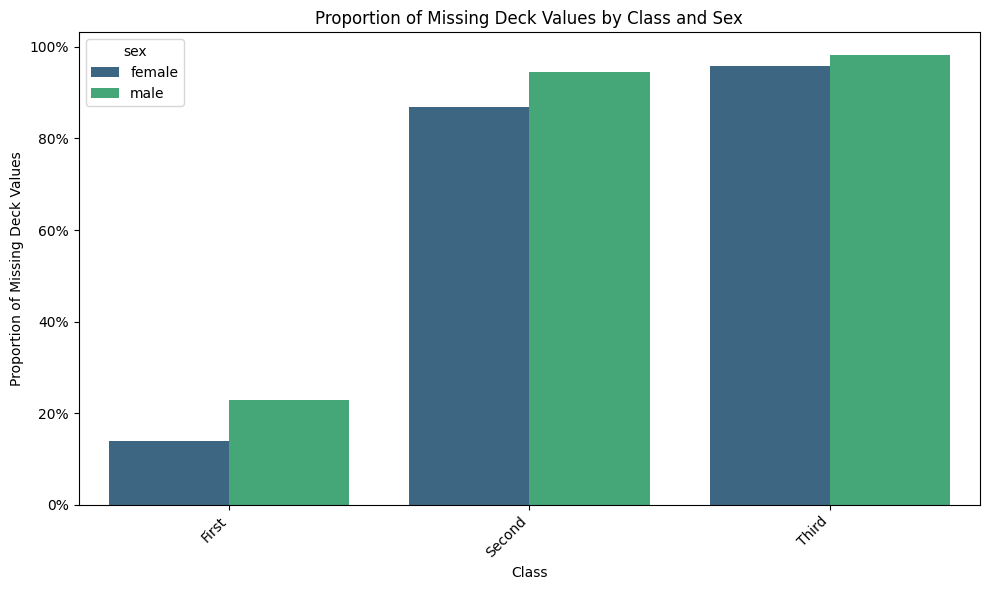

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns # Ensure seaborn is also imported if not globally available

plt.figure(figsize=(10, 6))
sns.barplot(
    x='class',
    y='missing_deck_ratio',
    hue='sex',
    data=missing_deck_proportion,
    palette='viridis'
)
plt.title('Proportion of Missing Deck Values by Class and Sex')
plt.xlabel('Class')
plt.ylabel('Proportion of Missing Deck Values')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

筆記:分析出頭等艙幾乎沒有損失艙等資料

原因:可能為二三等艙未登記甲板資料

年齡缺失資料分析

猜測與驗證:有成年男性/性別資料為完整資料，判斷是否可以從成年男性推測缺失年齡是否為男性未成年

In [26]:
# 篩選出年齡缺失的資料
missing_age_df = titanic_df[titanic_df['age'].isnull()]

# 從年齡缺失的資料中，找出性別為男性且非成年男性（即為兒童）的乘客
missing_age_male_children = missing_age_df[(missing_age_df['sex'] == 'male') & (missing_age_df['adult_male'] == False)]

# 計算這些乘客的數量
count_missing_age_male_children = len(missing_age_male_children)
total_missing_age = len(missing_age_df)

print(f"總年齡缺失人數: {total_missing_age}")
print(f"年齡缺失的非成年男性人數: {count_missing_age_male_children}")


display(missing_age_male_children.head())

總年齡缺失人數: 177
年齡缺失的非成年男性人數: 0


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,has_deck_info,has_age_info


筆記:未成年男性之際仔年齡皆正確，

年齡資料缺失只剩成年男性/成年女性/未成年女性

In [21]:
# 計算每個性別中年齡缺失的人數
missing_age_by_sex = titanic_df.groupby('sex')['age'].apply(lambda x: x.isnull().sum()).reset_index(name='missing_age_count')

# 計算每個性別的總人數
total_passengers_by_sex = titanic_df.groupby('sex').size().reset_index(name='total_passengers')

# 合併兩個DataFrame並計算年齡缺失比例
missing_age_sex_proportion = pd.merge(
    missing_age_by_sex,
    total_passengers_by_sex,
    on='sex'
)
missing_age_sex_proportion['missing_age_ratio'] = missing_age_sex_proportion['missing_age_count'] / missing_age_sex_proportion['total_passengers']

print("按性別分組的年齡缺失值計數及比例：")
display(missing_age_sex_proportion)

按性別分組的年齡缺失值計數及比例：


,sex,missing_age_count,total_passengers,missing_age_ratio
0,female,53,314,0.168790
1,male,124,577,0.214905


筆記:有124筆資料為成年男性但年齡資料缺失，可稍後判斷是否用平均成年男性年齡補足資料缺失(占總資料21.5%)

In [23]:
# 創建一個新的欄位 'has_age_info'，如果 'age' 不為空則為 True，否則為 False
titanic_df['has_age_info'] = titanic_df['age'].notna()

# 根據 'has_age_info' 分組計算生存率
survival_rate_by_age_info = titanic_df.groupby('has_age_info')['survived'].mean().reset_index()

# 將 True/False 轉換為更具描述性的標籤
survival_rate_by_age_info['age_info_status'] = survival_rate_by_age_info['has_age_info'].map({True: 'Has Age Info', False: 'Missing Age Info'})

print("按年齡資料完整性分組的生存率：")
display(survival_rate_by_age_info)

按年齡資料完整性分組的生存率：


,has_age_info,survived,age_info_status
0,False,0.293785,Missing Age Info
1,True,0.406162,Has Age Info


筆記:年齡缺失與生存率弱相關(10%)，接下來查驗同樣高度與生存率掛勾之艙等分析

In [25]:
# 篩選出年齡缺失的乘客
missing_age_passengers = titanic_df[titanic_df['age'].isnull()]

# 計算年齡缺失乘客中，每個艙等的數量
missing_age_pclass_distribution = missing_age_passengers['pclass'].value_counts().sort_index()

print("年齡缺失乘客中，船艙等級的分佈：")
display(missing_age_pclass_distribution)

年齡缺失乘客中，船艙等級的分佈：


,count
pclass,
1,30
2,11
3,136


結論:大部分年齡未登記為3艙等旅客

# 以視覺化圖表深入分析

筆記:
*  長條圖 `barplot` 用來離散類別的數值資料。圖表的高度代表平均值等統計數據
*  長方圖 `histplot` 畫出與連續數值相關的分布狀況。


將每一類印出其中有哪些以便後續使用統計

In [ ]:
display(titanic_df.columns) #此行為印出列(項目分類)
cols = titanic_df_category.columns #定義cols
cols

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

Index(['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive'], dtype='object')

In [ ]:
print("\nUnique values for object and category columns:")
for column in cols:
    print(f"\nColumn '{column}':")#
    display(titanic_df[column].unique())
    print()



Unique values for object and category columns:

Column 'sex':


array(['male', 'female'], dtype=object)



Column 'embarked':


array(['S', 'C', 'Q', nan], dtype=object)



Column 'class':


...

[NaN, 'C', 'E', 'G', 'D', 'A', 'B', 'F']
Categories (7, object): ['A', 'B', 'C', 'D', 'E', 'F', 'G']



Column 'embark_town':


array(['Southampton', 'Cherbourg', 'Queenstown', nan], dtype=object)



Column 'alive':


array(['no', 'yes'], dtype=object)

導入matplotlib以製作視覺化表格

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick


/tmp/ipykernel_1126/241756993.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


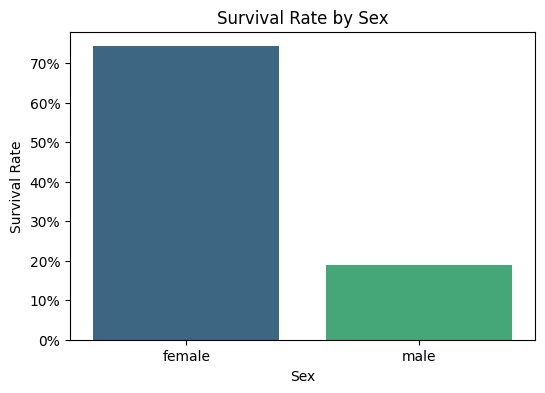

In [ ]:
# Calculate survival rate by sex
survival_rate_by_sex = titanic_df.groupby('sex')['survived'].mean().reset_index()


# Create the bar plot
plt.figure(figsize=(6, 4))
sns.barplot(
    x='sex',
    y='survived',
    data=survival_rate_by_sex,
    palette='viridis'
    )
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))#將縱軸換成%數表示

plt.show()

/tmp/ipykernel_1135/2799952727.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_rate_by_class = titanic_df.groupby('class')['survived'].mean().reset_index()
/tmp/ipykernel_1135/2799952727.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


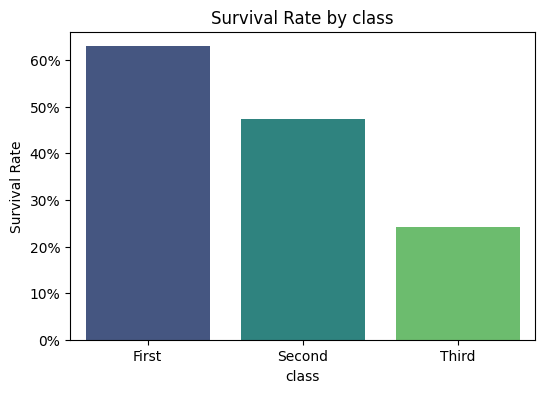

In [ ]:
# Calculate survival rate by class
survival_rate_by_class = titanic_df.groupby('class')['survived'].mean().reset_index()

# Create the bar plot
plt.figure(figsize=(6, 4))
sns.barplot(
    x='class',
    y='survived',
    data=survival_rate_by_class,
    palette='viridis' #顏色風格
    )
plt.title('Survival Rate by class')
plt.xlabel('class')
plt.ylabel('Survival Rate')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.show()

男女生存比例有差距先查詢登船性別比

In [ ]:
titanic_df['sex'].value_counts()

,count
sex,
male,577
female,314


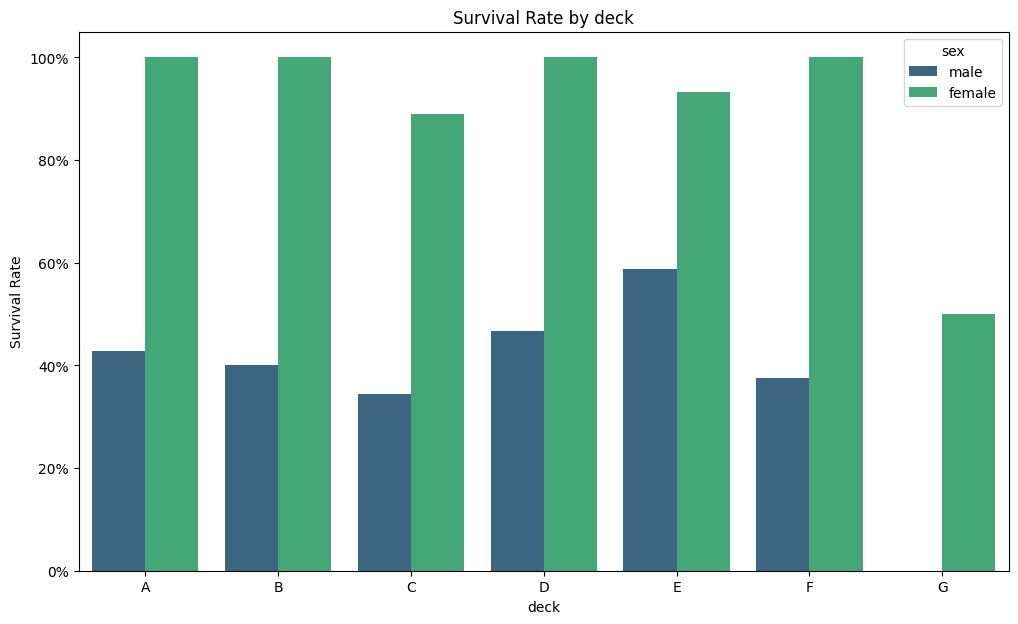

In [ ]:
# Create the bar plot
plt.figure(figsize=(12, 7))
sns.barplot(
    x='deck',
    y='survived',
    hue='sex',
    data=taitanic_df,
    palette='viridis',
    errorbar=None
    )
plt.title('Survival Rate by deck')
plt.xlabel('deck')
plt.ylabel('Survival Rate')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

first_class_df_with_deck = titanic_df[(titanic_df['pclass']==1) & (titanic_df['deck'].notna())]
first_class_df_with_deck

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
23,1,1,male,28.0,0,0,35.5000,S,First,man,True,A,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


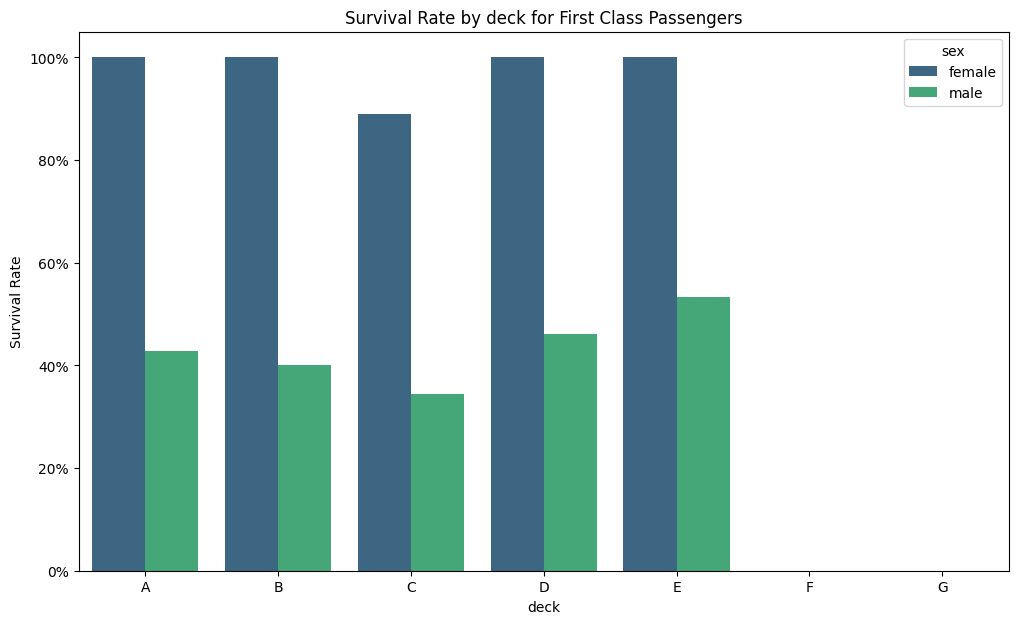

In [ ]:

plt.figure(figsize=(12, 7))
sns.barplot(
    x='deck',
    y='survived',
    hue='sex',
    data=first_class_df_with_deck,
    palette='viridis',
    errorbar=None
    )
plt.title('Survival Rate by deck for First Class Passengers')
plt.xlabel('deck')
plt.ylabel('Survival Rate')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.show()

In [ ]:
import numpy as np

# Filter for first-class passengers and create a new 'deck_group' column
first_class_df = titanic_df[titanic_df['pclass'] == 1].copy()

first_class_df['deck_group'] = first_class_df['deck'].apply(lambda x: 'A' if x == 'A' else ('C' if x == 'C' else ('Other' if pd.notna(x) else np.nan)))

# Calculate survival rate by the new deck group and sex
survival_rate_by_deck_group = first_class_df.groupby(['deck_group', 'sex'])['survived'].mean().reset_index()

display(survival_rate_by_deck_group)

,deck_group,sex,survived
0,A,female,1.000000
1,A,male,0.428571
2,C,female,0.888889
3,C,male,0.343750
4,Other,female,1.000000
5,Other,male,0.458333


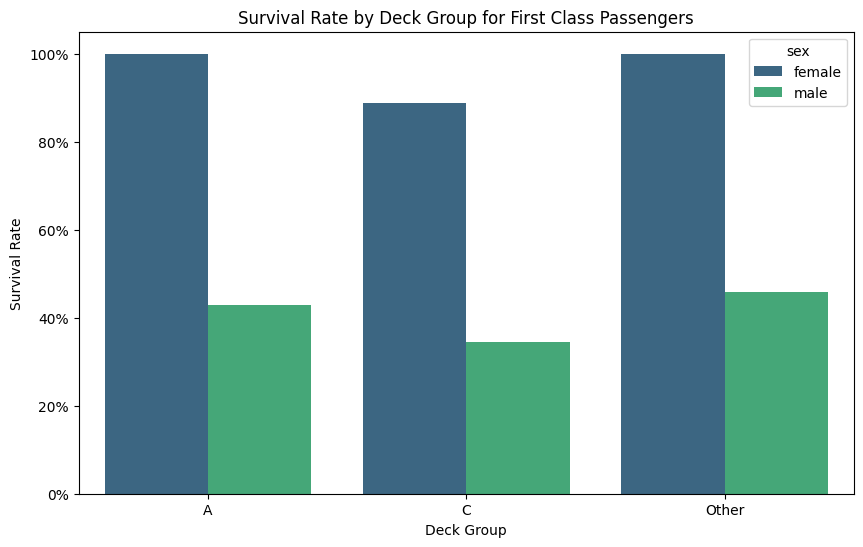

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x='deck_group',
    y='survived',
    hue='sex',
    data=survival_rate_by_deck_group,
    palette='viridis',
    errorbar=None
)
plt.title('Survival Rate by Deck Group for First Class Passengers')
plt.xlabel('Deck Group')
plt.ylabel('Survival Rate')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.show()

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(
    x='deck',
    y='survived',
    hue='sex',
    data=first_class_df_with_deck,
    palette='viridis',
    errorbar=None
    )
plt.title('Survival Rate by deck for First Class Passengers')
plt.xlabel('deck')
plt.ylabel('Survival Rate')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.show()

In [ ]:
# 頭等艙 且 有甲板資訊的
first_class_df_with_deck = titanic_df[(titanic_df['pclass']==1) & (titanic_df['deck'].notna())]
first_class_df_with_deck

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
23,1,1,male,28.0,0,0,35.5000,S,First,man,True,A,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


In [ ]:
def is_deck_a_g(deck_name):
    if deck_name=='A':
        return "Deck A"
    elif deck_name=='G':
        return "Deck G"
    else:
        return "Other Deck"
first_class_df_with_deck['deck_group'] = first_class_df_with_deck['deck'].apply(is_deck_a_g)
first_class_df_with_deck